In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import tqdm

projectPath = Path.cwd().parents[1]
print(projectPath)

c:\Users\Hannes\projects\paper-revision


In [2]:
datapath = projectPath / "data" / "z_norm"
df = pd.read_parquet(projectPath / "data" / "ivdata.parquet")

In [3]:
NUMBER_OF_SLICES_PER_CLUSTER = 1
SAMPLES_PER_SLICE = 20

def isValidSlice(key, group):
    z = group["z"].to_numpy()
    w = group["w"].to_numpy()
    
    validDataPoints = w.shape[0] - np.isnan(w).sum()
    
    return validDataPoints > 50
        

def sampleFromCluster(df):
    rng = np.random.default_rng()
    grouped = df.groupby(["Date", "Texp"])
    keys = list(grouped.groups.keys())

    selected = []
    tried = set()

    while len(selected) < NUMBER_OF_SLICES_PER_CLUSTER:
        if len(tried) == len(keys):
            raise RuntimeError("Not enough valid groups available.")

        group_idx = int(rng.integers(len(keys)))

        if group_idx in tried:
            continue

        tried.add(group_idx)

        key = keys[group_idx]
        group = grouped.get_group(key)

        if isValidSlice(key, group):
            selected.append(key)

    return selected


In [7]:
selectedKeys = []

for groupID, (groupLabel, group) in tqdm(list(enumerate(df.groupby("Group")))):
    keys = np.load(datapath / f"group_{groupID}_keys.npy", allow_pickle=True)
    labels = np.load(datapath / f"group_{groupID}_kmedoid_labels.npy")
    medoids = np.load(datapath / f"group_{groupID}_kmedoid_medoids.npy")
    
    for idx, cluster in enumerate(np.unique(labels), 1):
        keyIndex = pd.MultiIndex.from_tuples( [tuple(x) for x in keys[labels==cluster]], names=["Date", "Texp"])
        mask = pd.MultiIndex.from_frame(df[["Date", "Texp"]]).isin(keyIndex)
        selectedKeys += sampleFromCluster(df[mask])

100%|██████████| 5/5 [00:24<00:00,  4.89s/it]


In [18]:
def subsample(x, y, n):
    ix = np.linspace(x.min(), x.max(), n)
    return ix, np.interp(ix, x, y)

grouped = df.groupby(["Date", "Texp"])
data = [        ]
for category, key in enumerate(selectedKeys, 1):
    group = grouped.get_group(key)
    
    validMask = ~(group["w"].isna().to_numpy())
    z = group["z"].to_numpy()[validMask]
    w = group["w"].to_numpy()[validMask]
    
    w = w / w.max()
    z = z / abs(z).max()
    
    iz, iw = subsample(z, w, SAMPLES_PER_SLICE)
    
    data.append(np.array([
        iz, iw, category * np.ones_like(iz)
    ]).T)

    print("Total length", len(group))
    print("Valid data-points", len(group) - group["w"].isna().sum(), "->", group["w"].isna().sum(), "(NaN Values)")

data = np.vstack(data)
np.save(projectPath / "data" / "search" / "keys.npy", selectedKeys)
np.save(projectPath / "data" / "search" / "data.npy", data)

randCategory = np.random.randint(0, len(selectedKeys))
data = data[data[:, 2]==randCategory][:, [0, 1]]
np.save(projectPath / "data" / "search" / "data-simple.npy", data)

Total length 172
Valid data-points 73 -> 99 (NaN Values)
Total length 141
Valid data-points 105 -> 36 (NaN Values)
Total length 157
Valid data-points 139 -> 18 (NaN Values)
Total length 159
Valid data-points 149 -> 10 (NaN Values)
Total length 85
Valid data-points 78 -> 7 (NaN Values)
Total length 202
Valid data-points 75 -> 127 (NaN Values)
Total length 146
Valid data-points 133 -> 13 (NaN Values)
Total length 110
Valid data-points 109 -> 1 (NaN Values)
Total length 294
Valid data-points 279 -> 15 (NaN Values)
Total length 436
Valid data-points 433 -> 3 (NaN Values)
Total length 351
Valid data-points 330 -> 21 (NaN Values)
Total length 355
Valid data-points 347 -> 8 (NaN Values)
Total length 359
Valid data-points 354 -> 5 (NaN Values)
Total length 231
Valid data-points 223 -> 8 (NaN Values)
Total length 103
Valid data-points 103 -> 0 (NaN Values)
Total length 150
Valid data-points 143 -> 7 (NaN Values)
Total length 120
Valid data-points 120 -> 0 (NaN Values)
Total length 103
Valid dat

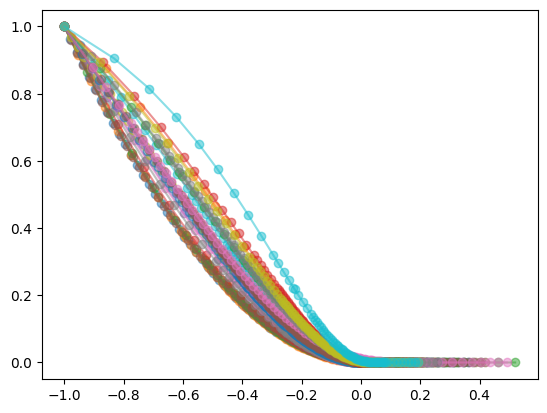

In [20]:
for category, key in enumerate(selectedKeys, 1):
    group = grouped.get_group(key)
    
    validMask = ~(group["w"].isna().to_numpy())
    z = group["z"].to_numpy()[validMask]
    w = group["w"].to_numpy()[validMask]
    
    w = w / w.max()
    z = z / abs(z).max()
    
    iz, iw = subsample(z, w, 20)
    
    plt.plot(z, w, alpha=0.5, marker="o")
plt.show()

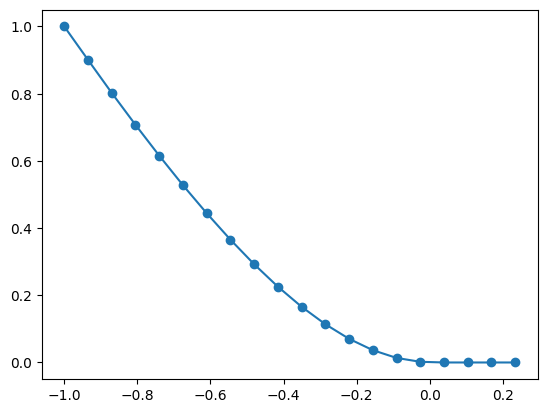

In [21]:
plt.plot(data[:, 0], data[:, 1], marker="o")